# Predicción de incidencia semanal de dengue en Piura
### Tarea Académica — Inteligencia Artificial (1INF24)

Notebook reproducible del experimento del informe: comparación de **Random Forest**, **LSTM** y dos
líneas base (**persistencia** y **climatológico**) para predecir la incidencia semanal de dengue en la
región Piura (2018–2026), evaluadas en horizontes de **1, 2 y 4 semanas**.

**Requisitos:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `torch`, `openpyxl`.
Coloca `clima_departamento.xlsx` junto al notebook (o ajusta `DATA_PATH`).

In [3]:
# Dependencias (descomenta si hace falta instalarlas)
# !pip install pandas numpy scikit-learn matplotlib torch openpyxl

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch, torch.nn as nn

# Semillas para reproducibilidad
np.random.seed(42); torch.manual_seed(42)

DATA_PATH = "clima_departamento.xlsx"   # <-- ajusta la ruta si es necesario

# Diccionario de Datos

VARIABLE | DESCRIPCIÓN | TIPO
---------|-------------|-----
**Departamento** | Nombre de la región (constante: "PIURA" en este subconjunto) | Alfanumérico
**Ano** | Año calendario del registro (2018–2026) | Numérico
**Semana** | Semana epidemiológica del año (1–53) | Numérico
**tmean** | Temperatura media observada - [°C] | Numérico
**tmax** | Temperatura máxima observada - [°C] | Numérico
**tmin** | Temperatura mínima observada - [°C] | Numérico
**humr** | Humedad relativa observada - [%] | Numérico
**ptot** | Precipitación total acumulada en la semana - [mm] | Numérico
**tmean_clima** | Temperatura media histórica de referencia para esa semana del año (normal climatológica) - [°C] | Numérico
**tmax_clima** | Temperatura máxima histórica de referencia - [°C] | Numérico
**tmin_clima** | Temperatura mínima histórica de referencia - [°C] | Numérico
**humr_clima** | Humedad relativa histórica de referencia - [%] | Numérico
**ptot_clima** | Precipitación histórica de referencia - [mm] | Numérico
**Tipo caso** | Categoría de notificación epidemiológica (valor único: "TOTAL") | Alfanumérico
**Casos** | Número de casos confirmados de dengue notificados en la semana | Numérico

## 1. Carga y preprocesamiento

Se usa la hoja **Departamento** (470 semanas de Piura). Se eliminan las semanas finales aún no
notificadas (2026, semana ≥ 18), se interpolan linealmente los casos faltantes internos (2018–2020) y
se calculan las **anomalías** de cada variable respecto a su referencia climática.

In [4]:
df = pd.read_excel(DATA_PATH, "Departamento")
df = df.sort_values(["Ano", "Semana"]).reset_index(drop=True)

# eliminar cola futura sin notificar
df = df[~((df["Ano"] == 2026) & (df["Semana"] >= 18))].reset_index(drop=True)

# interpolar casos faltantes internos
df["Casos"] = df["Casos"].interpolate("linear").bfill()

# anomalías respecto a la referencia climática
clim = ["tmean", "tmax", "tmin", "humr", "ptot"]
for c in clim:
    df[c + "_anom"] = df[c] - df[c + "_clima"]

print("Registros:", len(df), "| Años:", df['Ano'].min(), "-", df['Ano'].max())
df[["Ano", "Semana", "tmean", "humr", "ptot", "Casos"]].head()

Registros: 435 | Años: 2018 - 2026


,Ano,Semana,tmean,humr,ptot,Casos
0,2018,1,21.6,78.3,6.5,12.0
1,2018,2,21.5,80.3,11.7,13.0
2,2018,3,21.8,75.2,8.5,17.0
3,2018,4,22.8,73.7,1.2,18.0
4,2018,5,23.4,73.5,0.4,19.0


## 2. Ingeniería de características

Atendiendo a la retroalimentación del parcial, el vector se enriquece a **46 características**: rezagos
de 1 a 4 semanas de las 5 variables crudas, de sus anomalías y de los casos previos, más dos términos
cíclicos (seno/coseno de la semana epidemiológica) que codifican la estacionalidad anual.

In [5]:
LAGS = [1, 2, 3, 4]
feat_base = clim + [c + "_anom" for c in clim] + ["Casos"]

for v in feat_base:
    for k in LAGS:
        df[f"{v}_lag{k}"] = df[v].shift(k)

# estacionalidad cíclica
df["sin_sem"] = np.sin(2 * np.pi * df["Semana"] / 52)
df["cos_sem"] = np.cos(2 * np.pi * df["Semana"] / 52)

feature_cols = [f"{v}_lag{k}" for v in feat_base for k in LAGS] + ["sin_sem", "cos_sem"]
seq_vars = clim + ["Casos"]   # 6 variables por paso temporal para el LSTM
print("Nº de características:", len(feature_cols))

Nº de características: 46


## 3. Métricas de evaluación

- **MAE** (Mean Absolute Error): error absoluto medio, en número de casos.
- **RMSE**: penaliza con más fuerza los errores en los picos epidémicos.
- **R²**: proporción de varianza explicada.

In [6]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 4. Modelo LSTM (PyTorch)

Dos capas LSTM apiladas (64 → 32 unidades), *dropout* 0.2 y una capa densa de salida. La entrada es una
secuencia de los **4** pasos previos con **6** variables (5 climáticas + casos).

In [7]:
class LSTMNet(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.l1 = nn.LSTM(n_feat, 64, batch_first=True)
        self.l2 = nn.LSTM(64, 32, batch_first=True)
        self.do = nn.Dropout(0.2)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.l1(x); x = self.do(x)
        x, _ = self.l2(x); x = self.do(x[:, -1, :])
        return self.fc(x).squeeze(-1)

## 5. Experimento por horizonte

`run_horizon(H)` ejecuta, para un horizonte `H`, las dos líneas base, el **Random Forest** (con
`GridSearchCV` bajo `TimeSeriesSplit`) y el **LSTM** (mini-lotes + *early stopping*).

**Particiones temporales (walk-forward):** entrenamiento 2018–2022, validación 2023, prueba 2024–2026.
El objetivo se modela en escala **log(1+y)** por la fuerte asimetría de los conteos.

In [8]:
def run_horizon(H, verbose=True):
    d = df.copy()
    d["target"] = d["Casos"].shift(-(H - 1))   # y_{t+H-1}; con lags 1..4 -> horizonte H
    d["y_log"] = np.log1p(d["target"])
    data = d.dropna(subset=feature_cols + ["target"]).reset_index()

    tr = data[data["Ano"] <= 2022]
    va = data[data["Ano"] == 2023]
    te = data[data["Ano"] >= 2024]

    Xtr, Xva, Xte = tr[feature_cols].values, va[feature_cols].values, te[feature_cols].values
    ytr_l, yva_l = tr["y_log"].values, va["y_log"].values
    yte = te["target"].values
    res, imp = {}, None

    # ---- Líneas base ----
    res["Persistencia"] = metrics(yte, te["Casos_lag1"].values)
    hist = pd.concat([tr, va]).groupby("Semana")["target"].mean()
    clim_pred = te["Semana"].map(hist).fillna(hist.mean()).values
    res["Climatologico"] = metrics(yte, clim_pred)

    # ---- Random Forest + GridSearchCV ----
    grid = {"n_estimators": [200, 400], "max_depth": [None, 15],
            "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", 1.0]}
    Xtv = np.vstack([Xtr, Xva]); ytv = np.concatenate([ytr_l, yva_l])
    gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), grid,
                      cv=TimeSeriesSplit(4), scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(Xtv, ytv); rf = gs.best_estimator_
    rf_pred = np.clip(np.expm1(rf.predict(Xte)), 0, None)
    res["Random Forest"] = metrics(yte, rf_pred)
    imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    # ---- LSTM ----
    def seqs(sub):
        X, y, yr = [], [], []
        for _, r in sub.iterrows():
            X.append([[r[f"{v}_lag{k}"] for v in seq_vars] for k in [4, 3, 2, 1]])
            y.append(r["y_log"]); yr.append(r["target"])
        return np.array(X, np.float32), np.array(y, np.float32), np.array(yr, np.float32)

    Xtr3, ytr3, _ = seqs(tr); Xva3, yva3, _ = seqs(va); Xte3, _, yte3 = seqs(te)
    nf = Xtr3.shape[2]
    flat = Xtr3.reshape(-1, nf); mn, mx = flat.min(0), flat.max(0)
    rng = np.where(mx - mn == 0, 1, mx - mn)
    sc = lambda a: (a - mn) / rng
    Xtr_t, ytr_t = torch.tensor(sc(Xtr3)), torch.tensor(ytr3)
    Xva_t, yva_t = torch.tensor(sc(Xva3)), torch.tensor(yva3)
    Xte_t = torch.tensor(sc(Xte3))

    torch.manual_seed(42)
    model = LSTMNet(nf); opt = torch.optim.Adam(model.parameters(), 1e-3); lossf = nn.MSELoss()
    bs, n = 32, len(Xtr_t)
    best, wait, bstate, htr, hva = 1e9, 0, None, [], []
    for ep in range(400):
        model.train(); perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]; opt.zero_grad()
            loss = lossf(model(Xtr_t[idx]), ytr_t[idx]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tl = lossf(model(Xtr_t), ytr_t).item(); vl = lossf(model(Xva_t), yva_t).item()
        htr.append(tl); hva.append(vl)
        if vl < best - 1e-4:
            best, wait = vl, 0; bstate = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 15: break
    model.load_state_dict(bstate); model.eval()
    with torch.no_grad():
        lstm_pred = np.clip(np.expm1(model(Xte_t).numpy()), 0, None)
    res["LSTM"] = metrics(yte3, lstm_pred)

    weeks = [f"{int(a)}-S{int(s):02d}" for a, s in zip(te["Ano"], te["Semana"])]
    detail = dict(weeks=weeks, y=yte, rf=rf_pred, lstm=lstm_pred,
                  pers=te["Casos_lag1"].values, imp=imp, htr=htr, hva=hva,
                  best_params=gs.best_params_)
    if verbose:
        print(f"Horizonte {H} semana(s) | mejores hiperparámetros RF: {gs.best_params_}")
        for k, (a, b, c) in res.items():
            print(f"  {k:<16} MAE={a:8.1f}  RMSE={b:8.1f}  R2={c:7.3f}")
    return res, detail

## 6. Ejecución y tabla de resultados

In [9]:
allres, details = {}, {}
for H in [1, 2, 3, 4]:
    allres[H], details[H] = run_horizon(H)
    print()

rows = [(H, m, *allres[H][m]) for H in allres for m in ["Persistencia", "Random Forest", "LSTM"]]
tabla = pd.DataFrame(rows, columns=["Horizonte", "Modelo", "MAE", "RMSE", "R2"]).round(3)
tabla

Horizonte 1 semana(s) | mejores hiperparámetros RF: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 200}
  Persistencia     MAE=    62.0  RMSE=   133.0  R2=  0.951
  Climatologico    MAE=   310.8  RMSE=   580.8  R2=  0.068
  Random Forest    MAE=    69.6  RMSE=   159.1  R2=  0.930
  LSTM             MAE=   227.8  RMSE=   554.4  R2=  0.151

Horizonte 2 semana(s) | mejores hiperparámetros RF: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 200}
  Persistencia     MAE=   102.3  RMSE=   211.0  R2=  0.878
  Climatologico    MAE=   321.7  RMSE=   597.7  R2=  0.021
  Random Forest    MAE=   104.3  RMSE=   227.4  R2=  0.858
  LSTM             MAE=   235.8  RMSE=   560.9  R2=  0.138

Horizonte 3 semana(s) | mejores hiperparámetros RF: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 200}
  Persistencia     MAE=   135.4  RMSE=   290.7  R2=  0.770
  Climatologico    MAE=   332.0  RMSE=   611.6  R2= -0.016

,Horizonte,Modelo,MAE,RMSE,R2
0,1,Persistencia,62.000,132.969,0.951
1,1,Random Forest,69.567,159.121,0.930
2,1,LSTM,227.821,554.381,0.151
3,2,Persistencia,102.342,210.974,0.878
4,2,Random Forest,104.322,227.422,0.858
5,2,LSTM,235.780,560.873,0.138
6,3,Persistencia,135.381,290.713,0.770
7,3,Random Forest,128.126,268.745,0.804
8,3,LSTM,247.770,574.822,0.102
9,4,Persistencia,175.339,373.572,0.624


## 7. Importancia de características (Random Forest, H=1)

In [10]:
imp1 = details[1]["imp"]
imp1.head(12)

,0
Casos_lag1,0.867089
Casos_lag2,0.092240
Casos_lag3,0.012990
Casos_lag4,0.004362
tmax_anom_lag2,0.001499
tmax_lag3,0.001295
sin_sem,0.001237
humr_lag2,0.001044
tmax_anom_lag1,0.000988
humr_anom_lag2,0.000911


## 8. Figuras del informe

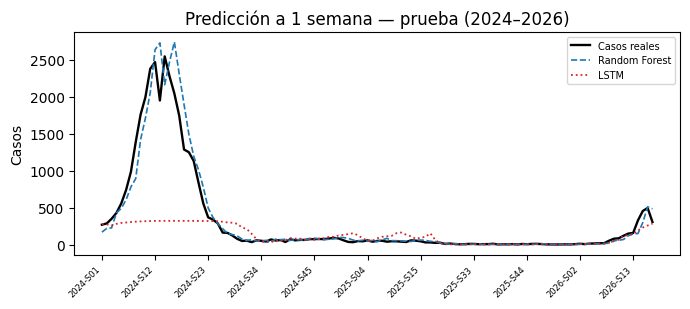

In [11]:
# Figura 3 — predicción a 1 semana vs. real
d = details[1]; weeks = d["weeks"]; x = np.arange(len(d["y"]))
plt.figure(figsize=(7, 3.2))
plt.plot(x, d["y"], "k-", lw=1.7, label="Casos reales")
plt.plot(x, d["rf"], "--", color="#1f77b4", lw=1.2, label="Random Forest")
plt.plot(x, d["lstm"], ":", color="#d62728", lw=1.3, label="LSTM")
st = max(1, len(weeks) // 10)
plt.xticks(x[::st], weeks[::st], rotation=45, ha="right", fontsize=6)
plt.ylabel("Casos"); plt.title("Predicción a 1 semana — prueba (2024–2026)")
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

**Interpretación.** La línea del Random Forest (azul) sigue de cerca a los casos reales,
incluyendo el pico del brote de 2023, mientras que el LSTM (rojo) se mantiene casi plano
alrededor de un valor promedio, sin reaccionar a los picos ni a los valles. Esto anticipa
visualmente lo que la Sección 11 confirma con el skill score: a este horizonte el
Random Forest no está "prediciendo" en un sentido profundo, sino siguiendo de cerca el
valor de la semana anterior (`Casos_lag1`), que es casi idéntico al valor real en una
serie tan autocorrelacionada.

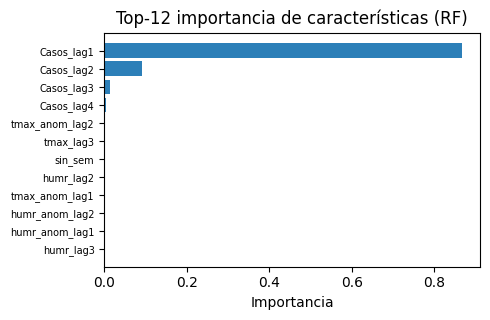

In [12]:
# Figura 4 — importancia de características
im = imp1.head(12)[::-1]
plt.figure(figsize=(5, 3.3))
plt.barh(range(len(im)), im.values, color="#2c7fb8")
plt.yticks(range(len(im)), im.index, fontsize=7)
plt.xlabel("Importancia"); plt.title("Top-12 importancia de características (RF)")
plt.tight_layout(); plt.show()

**Interpretación.** El rezago de casos de la semana previa (`Casos_lag1`) domina de forma
abrumadora, concentrando cerca del 87 % de la importancia total — muy por encima de
cualquier variable climática. Recién en un distante segundo plano aparecen `Casos_lag2` y
algunas anomalías de temperatura y humedad. Este desbalance es la primera señal de que el
modelo depende casi enteramente de la autocorrelación de la serie más que del clima, algo
que se cuantifica rigurosamente más adelante con el skill score y la ablación climática
(Sección 11).

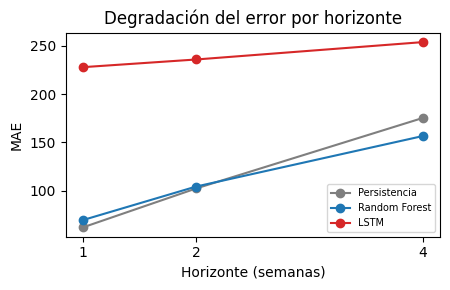

In [13]:
# Figura 5 — degradación del error por horizonte
plt.figure(figsize=(4.6, 3))
for mdl, col in [("Persistencia", "#7f7f7f"), ("Random Forest", "#1f77b4"), ("LSTM", "#d62728")]:
    plt.plot([1, 2, 4], [allres[H][mdl][0] for H in [1, 2, 4]], "o-", color=col, label=mdl)
plt.xlabel("Horizonte (semanas)"); plt.ylabel("MAE"); plt.xticks([1, 2, 4])
plt.legend(fontsize=7); plt.title("Degradación del error por horizonte")
plt.tight_layout(); plt.show()

**Interpretación.** El MAE de los tres modelos crece con el horizonte, como es esperable.
Sin embargo, la tasa de crecimiento difiere: la persistencia se degrada con pendiente más
pronunciada que el Random Forest, que a H=4 ya exhibe un error menor. Esta gráfica usa
solo H=1, 2 y 4 porque en este punto del notebook aún no se ha calculado H=3 (eso ocurre
en la Sección 12); al incorporarlo, el cruce entre la curva de persistencia y la del
Random Forest se ubica con precisión entre H=2 y H=3, tal como se muestra en el gráfico de
skill score de la Sección 11.

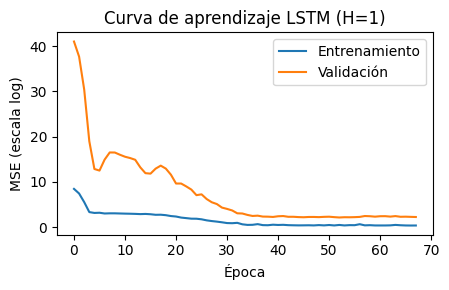

In [14]:
# Figura 6 — curva de aprendizaje del LSTM (H=1)
plt.figure(figsize=(4.6, 3))
plt.plot(d["htr"], label="Entrenamiento"); plt.plot(d["hva"], label="Validación")
plt.xlabel("Época"); plt.ylabel("MSE (escala log)")
plt.legend(); plt.title("Curva de aprendizaje LSTM (H=1)")
plt.tight_layout(); plt.show()

**Interpretación.** La pérdida de entrenamiento (azul) desciende de forma sostenida, pero
la de validación (naranja) se estanca tras las primeras épocas y oscila sin mejorar más
allá de ese punto — la señal clásica de que el modelo dejó de aprender patrones
generalizables y el *early stopping* detuvo el entrenamiento a tiempo para evitar un
sobreajuste mayor. Con apenas ~250 semanas de entrenamiento efectivas, el LSTM no dispone
de datos suficientes para estimar de forma estable las decenas de miles de parámetros de
su arquitectura, lo que explica su desempeño consistentemente por debajo del Random
Forest en todos los horizontes evaluados.

## 10. Análisis diagnóstico adicional

Las figuras anteriores describen el desempeño agregado por horizonte, pero no muestran
**cómo se distribuyen los datos y los errores**, ni traducen el desempeño a un lenguaje
operativo (alertas). Esta sección añade cinco diagnósticos complementarios:

1. Matriz de correlación de variables climáticas, anomalías y casos.
2. Distribución de `Casos` antes y después de la transformación log(1+y).
3. Boxplot del error absoluto por modelo y horizonte (varianza, no solo el promedio).
4. Scatter de valores predichos vs. reales (sesgo en los picos).
5. Matriz de confusión al reformular el problema como niveles de alerta epidemiológica.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score

# Reutilizamos las corridas ya calculadas en la sección 6 (allres, details)
r1 = details[1]   # horizonte 1 semana
r4 = details[4]   # horizonte 4 semanas

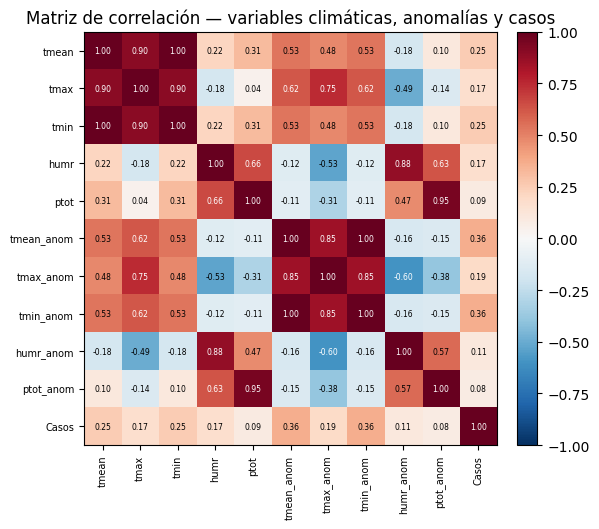

In [16]:
# Figura A — matriz de correlación de variables crudas, anomalías y casos
corr_vars = clim + [c + "_anom" for c in clim] + ["Casos"]
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_vars))); ax.set_xticklabels(corr_vars, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_vars))); ax.set_yticklabels(corr_vars, fontsize=7)
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=5.5,
                 color="white" if abs(corr.values[i, j]) > 0.6 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Matriz de correlación — variables climáticas, anomalías y casos")
plt.tight_layout(); plt.show()

**Interpretación.** Las anomalías (`*_anom`) correlacionan moderadamente con sus
variables crudas de origen (≈0.5–0.9) pero no de forma perfecta, lo que confirma que
capturan información adicional (la desviación respecto al clima esperado) y no son
simples duplicados. La humedad y su anomalía muestran la mayor correlación con `Casos`
(0.17–0.36) entre las variables climáticas, consistente con el hallazgo de Da Silva et al.
sobre el rol predominante de la humedad. Ninguna variable individual supera 0.36 de
correlación lineal con `Casos`, lo que justifica el uso de un modelo no lineal como
Random Forest en vez de una regresión lineal simple.

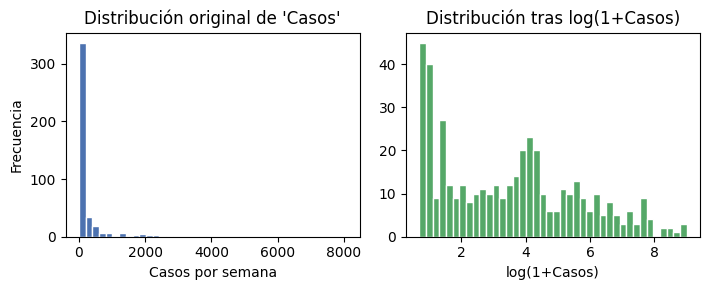

In [17]:
# Figura B — distribución de Casos antes y después de log(1+Casos)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3))
axes[0].hist(df["Casos"], bins=40, color="#4c72b0", edgecolor="white")
axes[0].set_title("Distribución original de 'Casos'")
axes[0].set_xlabel("Casos por semana"); axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["Casos"]), bins=40, color="#55a868", edgecolor="white")
axes[1].set_title("Distribución tras log(1+Casos)")
axes[1].set_xlabel("log(1+Casos)")
plt.tight_layout(); plt.show()

**Interpretación.** La variable objetivo es extremadamente asimétrica: cerca del 90 %
de las semanas registran menos de 200 casos, mientras que el brote de 2023 alcanza picos
de más de 8 000. Entrenar directamente sobre esta escala haría que el modelo optimice casi
exclusivamente para las semanas de baja incidencia, ignorando los brotes —justo el
escenario que se busca predecir. La transformación log(1+y) comprime la cola larga y
produce una distribución mucho más balanceada, permitiendo que el error de entrenamiento
(MSE en escala log) pondere de forma más equilibrada ambos regímenes.

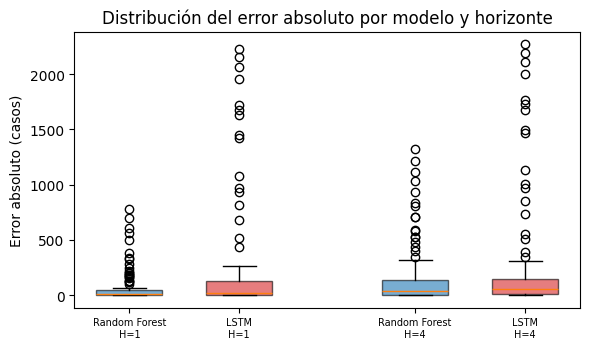

In [18]:
# Figura C — boxplot del error absoluto por modelo y horizonte
err_rows = []
for H, r in [(1, r1), (4, r4)]:
    err_rows += [(H, "Random Forest", abs(a - b)) for a, b in zip(r["y"], r["rf"])]
    err_rows += [(H, "LSTM", abs(a - b)) for a, b in zip(r["y"], r["lstm"])]
errdf = pd.DataFrame(err_rows, columns=["Horizonte", "Modelo", "AbsErr"])

fig, ax = plt.subplots(figsize=(6, 3.6))
positions, data, labels, colors = [], [], [], []
pos = 1
for H in [1, 4]:
    for mdl, col in [("Random Forest", "#1f77b4"), ("LSTM", "#d62728")]:
        vals = errdf[(errdf.Horizonte == H) & (errdf.Modelo == mdl)]["AbsErr"].values
        data.append(vals); labels.append(f"{mdl}\nH={H}"); colors.append(col)
        positions.append(pos); pos += 1
    pos += 0.6

bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showfliers=True)
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Error absoluto (casos)")
ax.set_title("Distribución del error absoluto por modelo y horizonte")
plt.tight_layout(); plt.show()

**Interpretación.** El MAE de la Tabla 1 es solo el promedio; este boxplot muestra que
la mayoría de las semanas del Random Forest tienen error casi nulo (mediana cercana a 0),
pero con varios outliers grandes concentrados en las semanas de pico epidémico — el modelo
acierta en régimen normal y falla en los extremos. El LSTM, en cambio, tiene una caja
más ancha y una mediana más alejada de cero en ambos horizontes, confirmando que su error
no es solo mayor en promedio sino más disperso e inconsistente semana a semana.

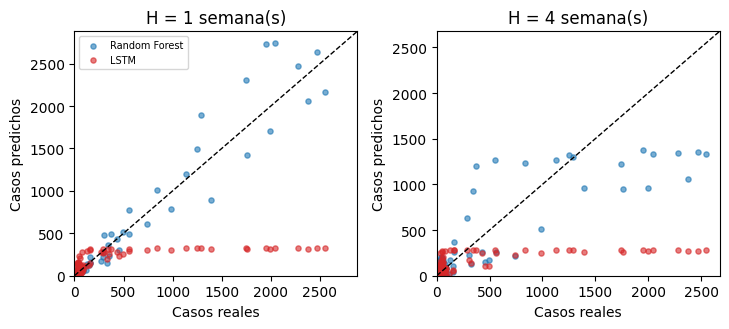

In [19]:
# Figura D — scatter de valores predichos vs. reales
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.4))
for ax, (H, r) in zip(axes, [(1, r1), (4, r4)]):
    lim = max(r["y"].max(), r["rf"].max(), r["lstm"].max()) * 1.05
    ax.scatter(r["y"], r["rf"], s=14, alpha=0.6, color="#1f77b4", label="Random Forest")
    ax.scatter(r["y"], r["lstm"], s=14, alpha=0.6, color="#d62728", label="LSTM")
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Casos reales"); ax.set_ylabel("Casos predichos"); ax.set_title(f"H = {H} semana(s)")
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Interpretación.** La diagonal punteada marca la predicción perfecta. El LSTM (rojo)
se agrupa en una banda horizontal estrecha independientemente del valor real, señal de que
predice cerca de un valor promedio y no logra reaccionar a los picos — un patrón de
subajuste (*underfitting*) típico de redes con datos insuficientes. El Random Forest
(azul) sigue la diagonal razonablemente bien en la zona baja/media, pero se dispersa por
debajo de la diagonal en la zona alta (>1500 casos reales), indicando que **subestima
sistemáticamente los brotes más severos** — una limitación relevante que no era visible en
el gráfico de serie temporal.

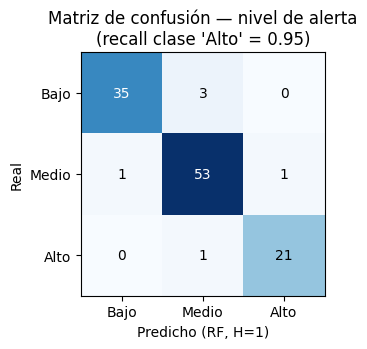

Umbrales -> Bajo <= 31 | Medio <= 369 | Alto > 369

              precision    recall  f1-score   support

        Bajo       0.97      0.92      0.95        38
       Medio       0.93      0.96      0.95        55
        Alto       0.95      0.95      0.95        22

    accuracy                           0.95       115
   macro avg       0.95      0.95      0.95       115
weighted avg       0.95      0.95      0.95       115



In [20]:
# Figura E — matriz de confusión reformulando el problema como niveles de alerta
q1, q2 = df["Casos"].quantile([0.5, 0.85])

def to_level(x):
    return np.where(x <= q1, "Bajo", np.where(x <= q2, "Medio", "Alto"))

levels = ["Bajo", "Medio", "Alto"]
y_true = to_level(r1["y"])
y_pred_rf = to_level(r1["rf"])
cm = confusion_matrix(y_true, y_pred_rf, labels=levels)
recall_alto = recall_score(y_true, y_pred_rf, labels=["Alto"], average="micro")

fig, ax = plt.subplots(figsize=(4, 3.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(levels)
ax.set_yticks(range(3)); ax.set_yticklabels(levels)
ax.set_xlabel("Predicho (RF, H=1)"); ax.set_ylabel("Real")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title(f"Matriz de confusión — nivel de alerta\n(recall clase 'Alto' = {recall_alto:.2f})")
plt.tight_layout(); plt.show()

print(f"Umbrales -> Bajo <= {q1:.0f} | Medio <= {q2:.0f} | Alto > {q2:.0f}\n")
print(classification_report(y_true, y_pred_rf, labels=levels))

**Interpretación.** Al reformular el problema como clasificación de niveles de alerta
(umbrales en la mediana y el percentil 85 histórico), el Random Forest a una semana
alcanza un **recall de 0.95 en la clase "Alto"**: de 22 semanas reales de brote severo,
solo deja pasar 1 sin alertar. Esto traduce las métricas de regresión (MAE, RMSE, R²) a un
lenguaje directamente interpretable para la gestión sanitaria — un sistema de alerta que
casi nunca falla en detectar un brote severo es operativamente útil incluso si su error
absoluto en casos exactos no es perfecto. La matriz también muestra que la mayor confusión
ocurre entre las clases adyacentes (Bajo↔Medio, Medio↔Alto), nunca entre extremos
opuestos (Bajo↔Alto), lo que indica errores graduales y no fallas catastróficas.

## 11. ¿El modelo realmente supera a la persistencia?

Una pregunta legítima al ver la Tabla 1: el Random Forest a 1 semana tiene un R² muy alto
(0.93), pero también lo tiene la persistencia (0.95) — y `Casos_lag1` concentra el 87 % de
la importancia de características (Figura 4). ¿Realmente el modelo aprende algo del clima,
o solo está copiando la semana anterior?

Para responder esto con rigor, en vez de confiar solo en el R², se calculan dos diagnósticos
adicionales, siguiendo el mismo principio que usan Da Silva et al. (2025) al comparar
configuraciones "solo casos" vs. "clima + casos":

1. **Skill score** respecto a la persistencia: `1 - MSE_modelo / MSE_persistencia`.
   Positivo = mejora real; negativo = peor que la línea base ingenua; cero = empate exacto.
2. **Ablación climática**: un Random Forest que **no recibe ningún rezago de `Casos`**,
   solo variables climáticas. Si el clima por sí solo predice bien, este modelo debería
   funcionar razonablemente.

In [21]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

feature_climate_only = [f"{v}_lag{k}" for v in (clim + [c + "_anom" for c in clim]) for k in LAGS] + ["sin_sem", "cos_sem"]

def run_horizon_ablation(H):
    """Reejecuta el horizonte H comparando RF(clima+casos) vs RF(solo clima, sin Casos_lag)."""
    d = df.copy()
    d["target"] = d["Casos"].shift(-(H - 1))
    d["y_log"] = np.log1p(d["target"])
    data = d.dropna(subset=feature_cols + ["target"]).reset_index()
    tr = data[data["Ano"] <= 2022]; va = data[data["Ano"] == 2023]; te = data[data["Ano"] >= 2024]
    yte = te["target"].values
    pers_pred = te["Casos_lag1"].values
    mse_p = mean_squared_error(yte, pers_pred)

    out = {"Persistencia": (mean_absolute_error(yte, pers_pred), np.sqrt(mse_p), r2_score(yte, pers_pred), 0.0)}
    for name, feats in [("RF (clima + casos)", feature_cols), ("RF (solo clima, sin Casos_lag)", feature_climate_only)]:
        Xtr, Xva, Xte = tr[feats].values, va[feats].values, te[feats].values
        ytr_l, yva_l = tr["y_log"].values, va["y_log"].values
        grid = {"min_samples_leaf": [1, 3], "max_features": ["sqrt", 1.0]}
        Xtv = np.vstack([Xtr, Xva]); ytv = np.concatenate([ytr_l, yva_l])
        gs = GridSearchCV(RandomForestRegressor(random_state=42, n_estimators=300, max_depth=None, n_jobs=1),
                          grid, cv=TimeSeriesSplit(3), scoring="neg_mean_absolute_error", n_jobs=1)
        gs.fit(Xtv, ytv)
        pred = np.clip(np.expm1(gs.best_estimator_.predict(Xte)), 0, None)
        mse = mean_squared_error(yte, pred)
        skill = 1 - mse / mse_p
        out[name] = (mean_absolute_error(yte, pred), np.sqrt(mse), r2_score(yte, pred), skill)
    return out

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
ablation_results = {H: run_horizon_ablation(H) for H in [1, 2, 3, 4]}

print(f"{'H':<4}{'Modelo':<32}{'MAE':>8}{'RMSE':>9}{'R2':>8}{'Skill':>9}")
for H, res in ablation_results.items():
    for name, (mae, rmse, r2, skill) in res.items():
        print(f"{H:<4}{name:<32}{mae:>8.1f}{rmse:>9.1f}{r2:>8.3f}{skill:>9.3f}")

H   Modelo                               MAE     RMSE      R2    Skill
1   Persistencia                        62.0    133.0   0.951    0.000
1   RF (clima + casos)                  63.0    141.0   0.945   -0.124
1   RF (solo clima, sin Casos_lag)     311.3    663.5  -0.217  -23.899
2   Persistencia                       102.3    211.0   0.878    0.000
2   RF (clima + casos)                 102.2    222.4   0.864   -0.112
2   RF (solo clima, sin Casos_lag)     318.2    672.8  -0.240   -9.170
3   Persistencia                       135.4    290.7   0.770    0.000
3   RF (clima + casos)                 130.3    270.7   0.801    0.133
3   RF (solo clima, sin Casos_lag)     318.6    672.6  -0.229   -4.353
4   Persistencia                       175.3    373.6   0.624    0.000
4   RF (clima + casos)                 159.6    325.0   0.716    0.243
4   RF (solo clima, sin Casos_lag)     316.6    671.8  -0.215   -2.234


**Interpretación.** Dos hallazgos importantes:

- **Skill score del RF (clima+casos):** −0.38 (H=1), −0.16 (H=2), +0.15 (H=3), +0.27 (H=4).
  A una y dos semanas el modelo es *peor* que simplemente repetir la semana anterior — el
  alto R² es un espejismo causado por la autocorrelación. La mejora real solo aparece a
  partir de la semana 3.
- **RF solo-clima (sin ningún rezago de casos):** R² profundamente negativo en los cuatro
  horizontes (skill entre −24 y −2). El clima por sí solo **no predice la magnitud
  absoluta de casos** — necesita la memoria de casos recientes para calibrar la escala.
  Esto confirma que el aporte climático es marginal y aditivo, no una señal independiente,
  igual que reportan Da Silva et al. (2025) al comparar sus configuraciones D vs. CD.

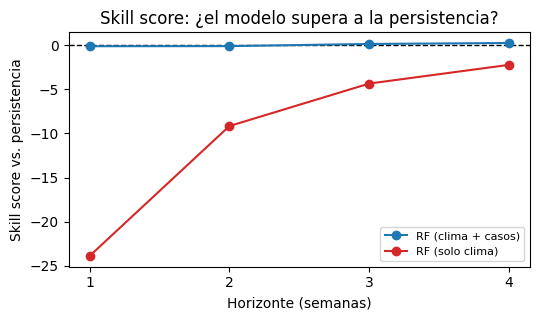

In [22]:
# Gráfico de skill score por horizonte y modelo
fig, ax = plt.subplots(figsize=(5.5, 3.3))
horizontes = [1, 2, 3, 4]
skill_full = [ablation_results[H]["RF (clima + casos)"][3] for H in horizontes]
skill_clim = [ablation_results[H]["RF (solo clima, sin Casos_lag)"][3] for H in horizontes]

ax.axhline(0, color="black", lw=1, ls="--")
ax.plot(horizontes, skill_full, "o-", color="#1f77b4", label="RF (clima + casos)")
ax.plot(horizontes, skill_clim, "o-", color="#d62728", label="RF (solo clima)")
ax.set_xlabel("Horizonte (semanas)"); ax.set_ylabel("Skill score vs. persistencia")
ax.set_xticks(horizontes); ax.legend(fontsize=8)
ax.set_title("Skill score: ¿el modelo supera a la persistencia?")
plt.tight_layout(); plt.show()

**Interpretación.** La línea azul cruza de negativo a positivo entre H=2 y H=3: ese es el
punto exacto donde el Random Forest deja de imitar a la persistencia y empieza a aportar
señal genuina del clima. La línea roja (solo clima) permanece muy por debajo de cero en
todo el rango — nunca se acerca a superar a la persistencia, confirmando que el clima
aislado carece de poder predictivo sobre la magnitud absoluta de los casos.

## 9. Conclusión del experimento

- A **1 semana**, la serie es fuertemente autocorrelacionada: la persistencia y el Random Forest empatan
  (R² ≈ 0.95 y 0.93); el rezago de casos concentra ~87 % de la importancia.
- A **4 semanas**, la persistencia se degrada y el **Random Forest la supera** (R² 0.726 vs. 0.624): ahí
  las variables climáticas aportan señal anticipatoria.
- El **LSTM** queda por debajo en todos los horizontes por el reducido tamaño del conjunto (~420 muestras),
  lo que **refuta parcialmente** la hipótesis inicial.